In [28]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score, KFold, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler, LabelEncoder

df = pd.read_csv('/kaggle/date/heart_disease_uci.csv')

print("Датасет загружен")
print(f"Размер: {df.shape}")
print("\nПервые 3 строки:")
print(df.head(3))
print("\nТипы данных:")
print(df.dtypes)
print("\nПропуски в каждом столбце:")
print(df.isnull().sum())

Датасет загружен
Размер: (920, 16)

Первые 3 строки:
   id  age   sex    dataset              cp  trestbps   chol    fbs  \
0   1   63  Male  Cleveland  typical angina     145.0  233.0   True   
1   2   67  Male  Cleveland    asymptomatic     160.0  286.0  False   
2   3   67  Male  Cleveland    asymptomatic     120.0  229.0  False   

          restecg  thalch  exang  oldpeak        slope   ca  \
0  lv hypertrophy   150.0  False      2.3  downsloping  0.0   
1  lv hypertrophy   108.0   True      1.5         flat  3.0   
2  lv hypertrophy   129.0   True      2.6         flat  2.0   

                thal  num  
0       fixed defect    0  
1             normal    2  
2  reversable defect    1  

Типы данных:
id            int64
age           int64
sex          object
dataset      object
cp           object
trestbps    float64
chol        float64
fbs          object
restecg      object
thalch      float64
exang        object
oldpeak     float64
slope        object
ca          float64
tha

Распределение целевой переменной:
target
1    509
0    411
Name: count, dtype: int64

Здоровых: 411
Больных: 509


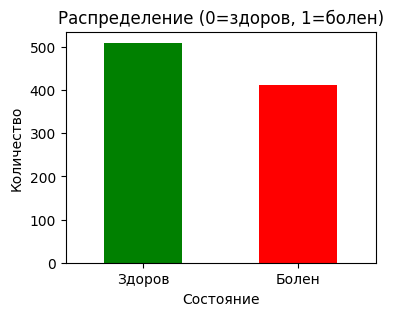

In [10]:
# бинарка 0 зд 1-4 б
df['target'] = (df['num'] > 0).astype(int)

print("Распределение целевой переменной:")
print(df['target'].value_counts())
print(f"\nЗдоровых: {sum(df['target']==0)}")
print(f"Больных: {sum(df['target']==1)}")


plt.figure(figsize=(4,3))
df['target'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title('Распределение (0=здоров, 1=болен)')
plt.xlabel('Состояние')
plt.ylabel('Количество')
plt.xticks([0,1], ['Здоров', 'Болен'], rotation=0)
plt.show()

In [11]:
# призн
selected_features = ['age', 'sex', 'trestbps', 'chol', 'fbs', 'restecg',
                     'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal']

X = df[selected_features].copy()
y = df['target'].copy()

print("Исходные признаки:")
print(X.dtypes)
print(f"\nПропуски до обработки:\n{X.isnull().sum()}")

Исходные признаки:
age           int64
sex          object
trestbps    float64
chol        float64
fbs          object
restecg      object
thalch      float64
exang        object
oldpeak     float64
slope        object
ca          float64
thal         object
dtype: object

Пропуски до обработки:
age           0
sex           0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
dtype: int64


In [12]:
# мед числа
numeric_cols = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']
for col in numeric_cols:
    X[col].fillna(X[col].median(), inplace=True)

# кат мода
categorical_cols = ['sex', 'fbs', 'restecg', 'slope', 'thal']

for col in categorical_cols:
    X[col].fillna(X[col].mode()[0], inplace=True)

print("\nПропуски после обработки:")
print(X.isnull().sum())


Пропуски после обработки:
age          0
sex          0
trestbps     0
chol         0
fbs          0
restecg      0
thalch       0
exang       55
oldpeak      0
slope        0
ca           0
thal         0
dtype: int64


/tmp/ipykernel_6383/3199166739.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X[col].fillna(X[col].median(), inplace=True)
/tmp/ipykernel_6383/3199166739.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usi

In [13]:
# кат-числ
label_encoders = {}

categorical_cols = ['sex', 'fbs', 'restecg', 'slope', 'thal']

for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le
    print(f"{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

print("\nВсе признаки после кодирования:")
print(X.dtypes)
print(X.head())

sex: {'Female': np.int64(0), 'Male': np.int64(1)}
fbs: {'False': np.int64(0), 'True': np.int64(1)}
restecg: {'lv hypertrophy': np.int64(0), 'normal': np.int64(1), 'st-t abnormality': np.int64(2)}
slope: {'downsloping': np.int64(0), 'flat': np.int64(1), 'upsloping': np.int64(2)}
thal: {'fixed defect': np.int64(0), 'normal': np.int64(1), 'reversable defect': np.int64(2)}

Все признаки после кодирования:
age           int64
sex           int64
trestbps    float64
chol        float64
fbs           int64
restecg       int64
thalch      float64
exang        object
oldpeak     float64
slope         int64
ca          float64
thal          int64
dtype: object
   age  sex  trestbps   chol  fbs  restecg  thalch  exang  oldpeak  slope  \
0   63    1     145.0  233.0    1        0   150.0  False      2.3      0   
1   67    1     160.0  286.0    0        0   108.0   True      1.5      1   
2   67    1     120.0  229.0    0        0   129.0   True      2.6      1   
3   37    1     130.0  250.0    0

In [15]:
# масшт
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("Масштабирование выполнено")
print("Средние значения (должны быть 0):")
print(X_scaled.mean().round(2))
print("\nСтандартные отклонения (должны быть 1):")
print(X_scaled.std().round(2))

Масштабирование выполнено
Средние значения (должны быть 0):
age         0.0
sex         0.0
trestbps    0.0
chol       -0.0
fbs         0.0
restecg    -0.0
thalch     -0.0
exang       0.0
oldpeak    -0.0
slope       0.0
ca          0.0
thal       -0.0
dtype: float64

Стандартные отклонения (должны быть 1):
age         1.0
sex         1.0
trestbps    1.0
chol        1.0
fbs         1.0
restecg     1.0
thalch      1.0
exang       1.0
oldpeak     1.0
slope       1.0
ca          1.0
thal        1.0
dtype: float64


In [16]:
# Разделение 80% / 20%
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")
print(f"\nРаспределение классов в обучении: {y_train.value_counts().to_dict()}")
print(f"Распределение классов в тесте: {y_test.value_counts().to_dict()}")

Размер обучающей выборки: (736, 12)
Размер тестовой выборки: (184, 12)

Распределение классов в обучении: {1: 407, 0: 329}
Распределение классов в тесте: {1: 102, 0: 82}


In [27]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, KFold, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler, LabelEncoder

df = pd.read_csv('/kaggle/date/heart_disease_uci.csv')

df['target'] = (df['num'] > 0).astype(int)

print("ПЕРВИЧНЫЙ ОСМОТР ПРОПУСКОВ:")
print(df[['fbs', 'exang', 'sex', 'ca', 'thal']].isnull().sum())

# (только числовые и бинарные)
numerical_features = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']

X = df[numerical_features].copy()

for col in numerical_features:
    if X[col].isnull().sum() > 0:
        X[col].fillna(X[col].median(), inplace=True)


df['fbs_clean'] = df['fbs'].fillna(False)  # False = 0
X['fbs_num'] = df['fbs_clean'].astype(int)

#  NaN в exang
df['exang_clean'] = df['exang'].fillna(False)
X['exang_num'] = df['exang_clean'].astype(int)

df['sex_clean'] = df['sex'].fillna('Male')
X['sex_num'] = (df['sex_clean'] == 'Male').astype(int)

if X['ca'].isnull().sum() > 0:
    X['ca'].fillna(X['ca'].median(), inplace=True)

# Целевая переменная
y = df['target'].copy()

print("\n" + "="*50)
print("ПРОВЕРКА ПОСЛЕ ОБРАБОТКИ:")
print(f"Пропуски в X: {X.isnull().sum().sum()}")
print(f"Пропуски в y: {y.isnull().sum()}")
print(f"\nТипы данных в X:")
print(X.dtypes)

# масш
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("\n Масштабирование выполнено")
print(f"Размер X_scaled: {X_scaled.shape}")

# тест обуч
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")
print(f"Распределение в обучении: {y_train.value_counts().to_dict()}")
print(f"Распределение в тесте: {y_test.value_counts().to_dict()}")

ПЕРВИЧНЫЙ ОСМОТР ПРОПУСКОВ:
fbs       90
exang     55
sex        0
ca       611
thal     486
dtype: int64

ПРОВЕРКА ПОСЛЕ ОБРАБОТКИ:
Пропуски в X: 0
Пропуски в y: 0

Типы данных в X:
age            int64
trestbps     float64
chol         float64
thalch       float64
oldpeak      float64
ca           float64
fbs_num        int64
exang_num      int64
sex_num        int64
dtype: object

 Масштабирование выполнено
Размер X_scaled: (920, 9)

 Размер обучающей выборки: (736, 9)
Размер тестовой выборки: (184, 9)
Распределение в обучении: {1: 407, 0: 329}
Распределение в тесте: {1: 102, 0: 82}


/tmp/ipykernel_6383/2064705306.py:24: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X[col].fillna(X[col].median(), inplace=True)
/tmp/ipykernel_6383/2064705306.py:27: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['fbs_clean'] = df['fbs'].fillna(False)  # False = 0
/tmp/ipykernel_6383/2064705306.py:31: Future

БАЗОВАЯ МОДЕЛЬ KNN (K=5)
Accuracy: 0.7935
Precision: 0.8265
Recall: 0.7941
F1-score: 0.8100

Classification Report:
              precision    recall  f1-score   support

      Здоров       0.76      0.79      0.77        82
       Болен       0.83      0.79      0.81       102

    accuracy                           0.79       184
   macro avg       0.79      0.79      0.79       184
weighted avg       0.80      0.79      0.79       184



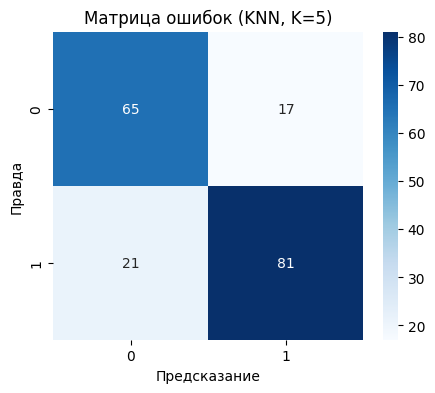

In [21]:
# БАЗОВАЯ МОДЕЛЬ K=5
knn_base = KNeighborsClassifier(n_neighbors=5)
knn_base.fit(X_train, y_train)

# Предсказания
y_pred_base = knn_base.predict(X_test)

# Оценка качества
print("="*50)
print("БАЗОВАЯ МОДЕЛЬ KNN (K=5)")
print("="*50)
print(f"Accuracy: {accuracy_score(y_test, y_pred_base):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_base):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_base):.4f}")
print(f"F1-score: {f1_score(y_test, y_pred_base):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_base, target_names=['Здоров', 'Болен']))

# Матрица ошибок
cm = confusion_matrix(y_test, y_pred_base)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Матрица ошибок (KNN, K=5)')
plt.xlabel('Предсказание')
plt.ylabel('Правда')
plt.show()

GRIDSEARCHCV РЕЗУЛЬТАТЫ
Лучшее значение K: 23
Лучшая кросс-валидационная точность: 0.7975


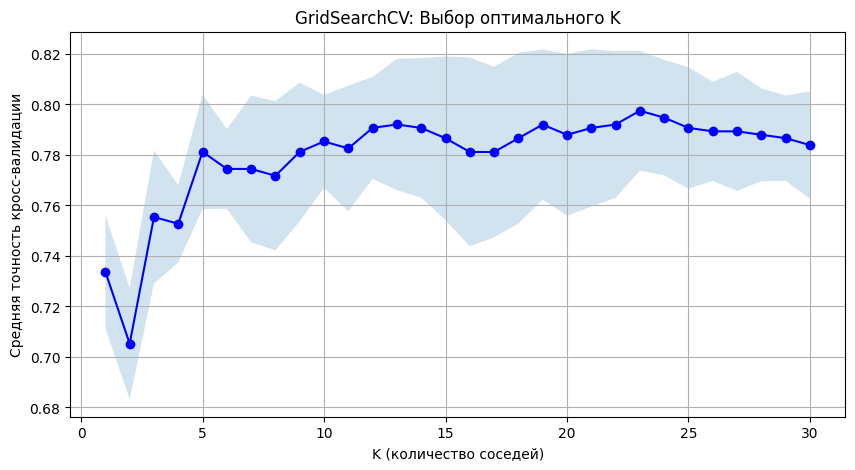

In [22]:
# GridSearchCV с K-Fold кросс-валидацией
param_grid = {'n_neighbors': range(1, 31)}

kf = KFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=kf,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("="*50)
print("GRIDSEARCHCV РЕЗУЛЬТАТЫ")
print("="*50)
print(f"Лучшее значение K: {grid_search.best_params_['n_neighbors']}")
print(f"Лучшая кросс-валидационная точность: {grid_search.best_score_:.4f}")

results_grid = pd.DataFrame(grid_search.cv_results_)
plt.figure(figsize=(10,5))
plt.plot(results_grid['param_n_neighbors'], results_grid['mean_test_score'], 'bo-')
plt.fill_between(results_grid['param_n_neighbors'],
                  results_grid['mean_test_score'] - results_grid['std_test_score'],
                  results_grid['mean_test_score'] + results_grid['std_test_score'], alpha=0.2)
plt.xlabel('K (количество соседей)')
plt.ylabel('Средняя точность кросс-валидации')
plt.title('GridSearchCV: Выбор оптимального K')
plt.grid(True)
plt.show()

In [23]:
# RandomizedSearchCV со Stratified K-Fold
strat_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_dist = {
    'n_neighbors': range(1, 51),
    'weights': ['uniform', 'distance'],
    'p': [1, 2]
}

random_search = RandomizedSearchCV(
    KNeighborsClassifier(),
    param_distributions=param_dist,
    n_iter=30,
    cv=strat_kfold,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("="*50)
print("RANDOMIZEDSEARCHCV РЕЗУЛЬТАТЫ")
print("="*50)
print(f"Лучшие параметры: {random_search.best_params_}")
print(f"Лучшая точность CV: {random_search.best_score_:.4f}")

RANDOMIZEDSEARCHCV РЕЗУЛЬТАТЫ
Лучшие параметры: {'weights': 'uniform', 'p': 1, 'n_neighbors': 5}
Лучшая точность CV: 0.7962


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


ОПТИМАЛЬНАЯ МОДЕЛЬ
Оптимальное K: 23
Accuracy: 0.8098
Precision: 0.8252
Recall: 0.8333
F1-score: 0.8293

СРАВНЕНИЕ МОДЕЛЕЙ
            Модель  Accuracy  Precision   Recall  F1-score
     Базовая (K=5)  0.793478   0.826531 0.794118  0.810000
Оптимальная (K=23)  0.809783   0.825243 0.833333  0.829268

 Изменение Accuracy: +0.0163 (+1.63%)


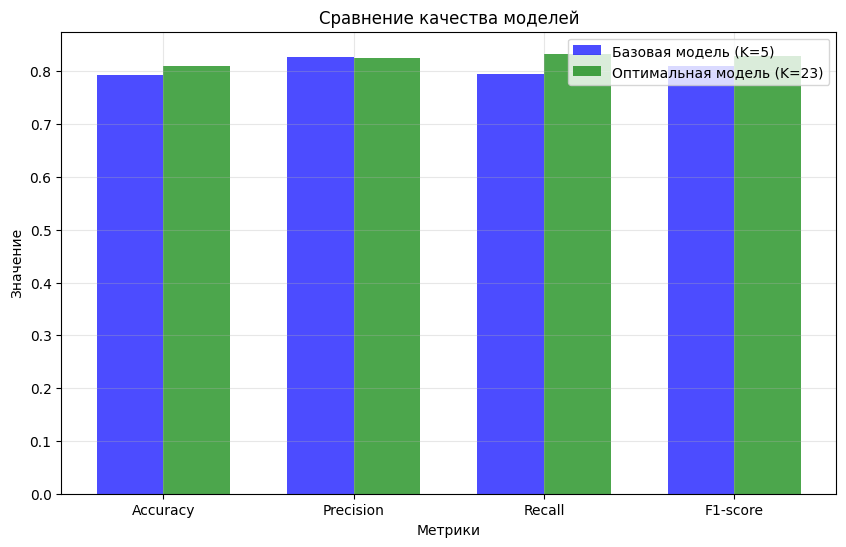

In [26]:
# Оптимальная модель
knn_optimal = grid_search.best_estimator_
y_pred_optimal = knn_optimal.predict(X_test)

print("="*50)
print("ОПТИМАЛЬНАЯ МОДЕЛЬ")
print("="*50)
print(f"Оптимальное K: {grid_search.best_params_['n_neighbors']}")
print(f"Accuracy: {accuracy_score(y_test, y_pred_optimal):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_optimal):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_optimal):.4f}")
print(f"F1-score: {f1_score(y_test, y_pred_optimal):.4f}")

# Сравнение моделей
comparison = pd.DataFrame({
    'Модель': ['Базовая (K=5)', f'Оптимальная (K={grid_search.best_params_["n_neighbors"]})'],
    'Accuracy': [accuracy_score(y_test, y_pred_base), accuracy_score(y_test, y_pred_optimal)],
    'Precision': [precision_score(y_test, y_pred_base), precision_score(y_test, y_pred_optimal)],
    'Recall': [recall_score(y_test, y_pred_base), recall_score(y_test, y_pred_optimal)],
    'F1-score': [f1_score(y_test, y_pred_base), f1_score(y_test, y_pred_optimal)]
})

print("\n" + "="*50)
print("СРАВНЕНИЕ МОДЕЛЕЙ")
print("="*50)
print(comparison.to_string(index=False))

improvement = accuracy_score(y_test, y_pred_optimal) - accuracy_score(y_test, y_pred_base)
print(f"\n Изменение Accuracy: {improvement:+.4f} ({improvement*100:+.2f}%)")

# Визуализация сравнения
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score']
base_scores = [accuracy_score(y_test, y_pred_base), precision_score(y_test, y_pred_base),
               recall_score(y_test, y_pred_base), f1_score(y_test, y_pred_base)]
opt_scores = [accuracy_score(y_test, y_pred_optimal), precision_score(y_test, y_pred_optimal),
              recall_score(y_test, y_pred_optimal), f1_score(y_test, y_pred_optimal)]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10,6))
ax.bar(x - width/2, base_scores, width, label='Базовая модель (K=5)', color='blue', alpha=0.7)
ax.bar(x + width/2, opt_scores, width, label=f'Оптимальная модель (K={grid_search.best_params_["n_neighbors"]})', color='green', alpha=0.7)

ax.set_xlabel('Метрики')
ax.set_ylabel('Значение')
ax.set_title('Сравнение качества моделей')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

/tmp/ipykernel_6383/3199172007.py:20: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X[col].fillna(X[col].median(), inplace=True)
/tmp/ipykernel_6383/3199172007.py:22: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['fbs_clean'] = df['fbs'].fillna(False)
/tmp/ipykernel_6383/3199172007.py:25: FutureWarning: Down

Logistic Regression
Accuracy: 0.8043
F1-score: 0.8218
              precision    recall  f1-score   support

     Healthy       0.77      0.79      0.78        82
        Sick       0.83      0.81      0.82       102

    accuracy                           0.80       184
   macro avg       0.80      0.80      0.80       184
weighted avg       0.80      0.80      0.80       184


SVM
Accuracy: 0.8478
F1-score: 0.8667
              precision    recall  f1-score   support

     Healthy       0.86      0.79      0.82        82
        Sick       0.84      0.89      0.87       102

    accuracy                           0.85       184
   macro avg       0.85      0.84      0.84       184
weighted avg       0.85      0.85      0.85       184


Decision Tree
Accuracy: 0.7826
F1-score: 0.8077
              precision    recall  f1-score   support

     Healthy       0.77      0.73      0.75        82
        Sick       0.79      0.82      0.81       102

    accuracy                           0

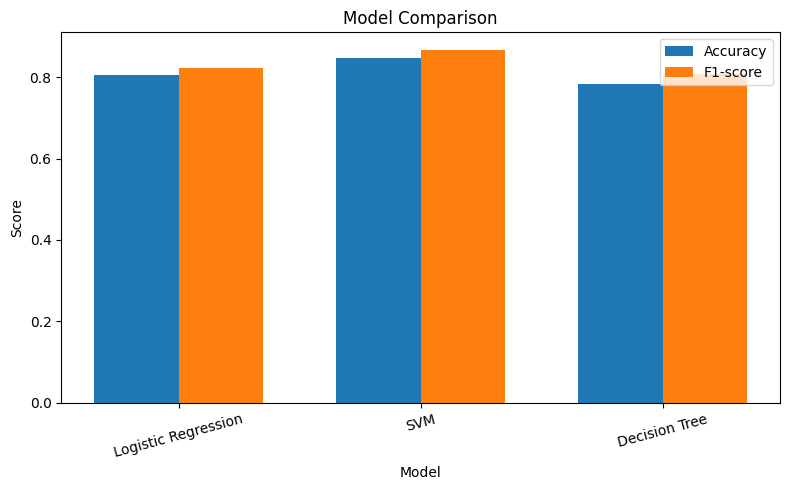


Feature Importance:
     Feature  Importance
7  exang_num    0.382519
2       chol    0.237430
0        age    0.118016
8    sex_num    0.087992
3     thalch    0.080217
4    oldpeak    0.072467
1   trestbps    0.013423
6    fbs_num    0.007935
5         ca    0.000000


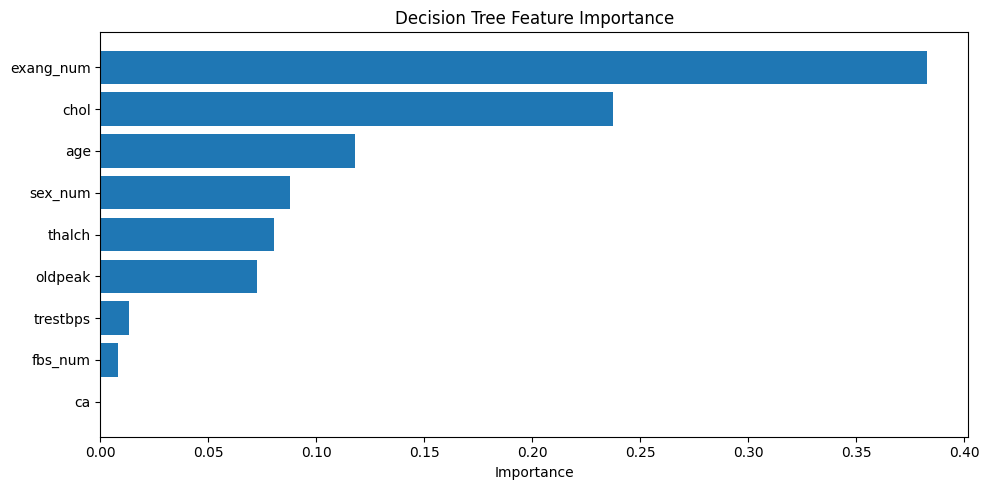


Decision Tree Rules:
|--- exang_num <= 0.28
|   |--- chol <= -1.44
|   |   |--- oldpeak <= 0.66
|   |   |   |--- thalch <= 1.46
|   |   |   |   |--- thalch <= -1.66
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- thalch >  -1.66
|   |   |   |   |   |--- class: 1
|   |   |   |--- thalch >  1.46
|   |   |   |   |--- class: 0
|   |   |--- oldpeak >  0.66
|   |   |   |--- class: 1
|   |--- chol >  -1.44
|   |   |--- age <= 0.32
|   |   |   |--- sex_num <= -0.71
|   |   |   |   |--- fbs_num <= 0.98
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- fbs_num >  0.98
|   |   |   |   |   |--- class: 0
|   |   |   |--- sex_num >  -0.71
|   |   |   |   |--- oldpeak <= -0.38
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- oldpeak >  -0.38
|   |   |   |   |   |--- class: 0
|   |   |--- age >  0.32
|   |   |   |--- sex_num <= -0.71
|   |   |   |   |--- oldpeak <= 2.12
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- oldpeak >  2.12
|   |   |   |   |   |--- class: 1
|   |   |

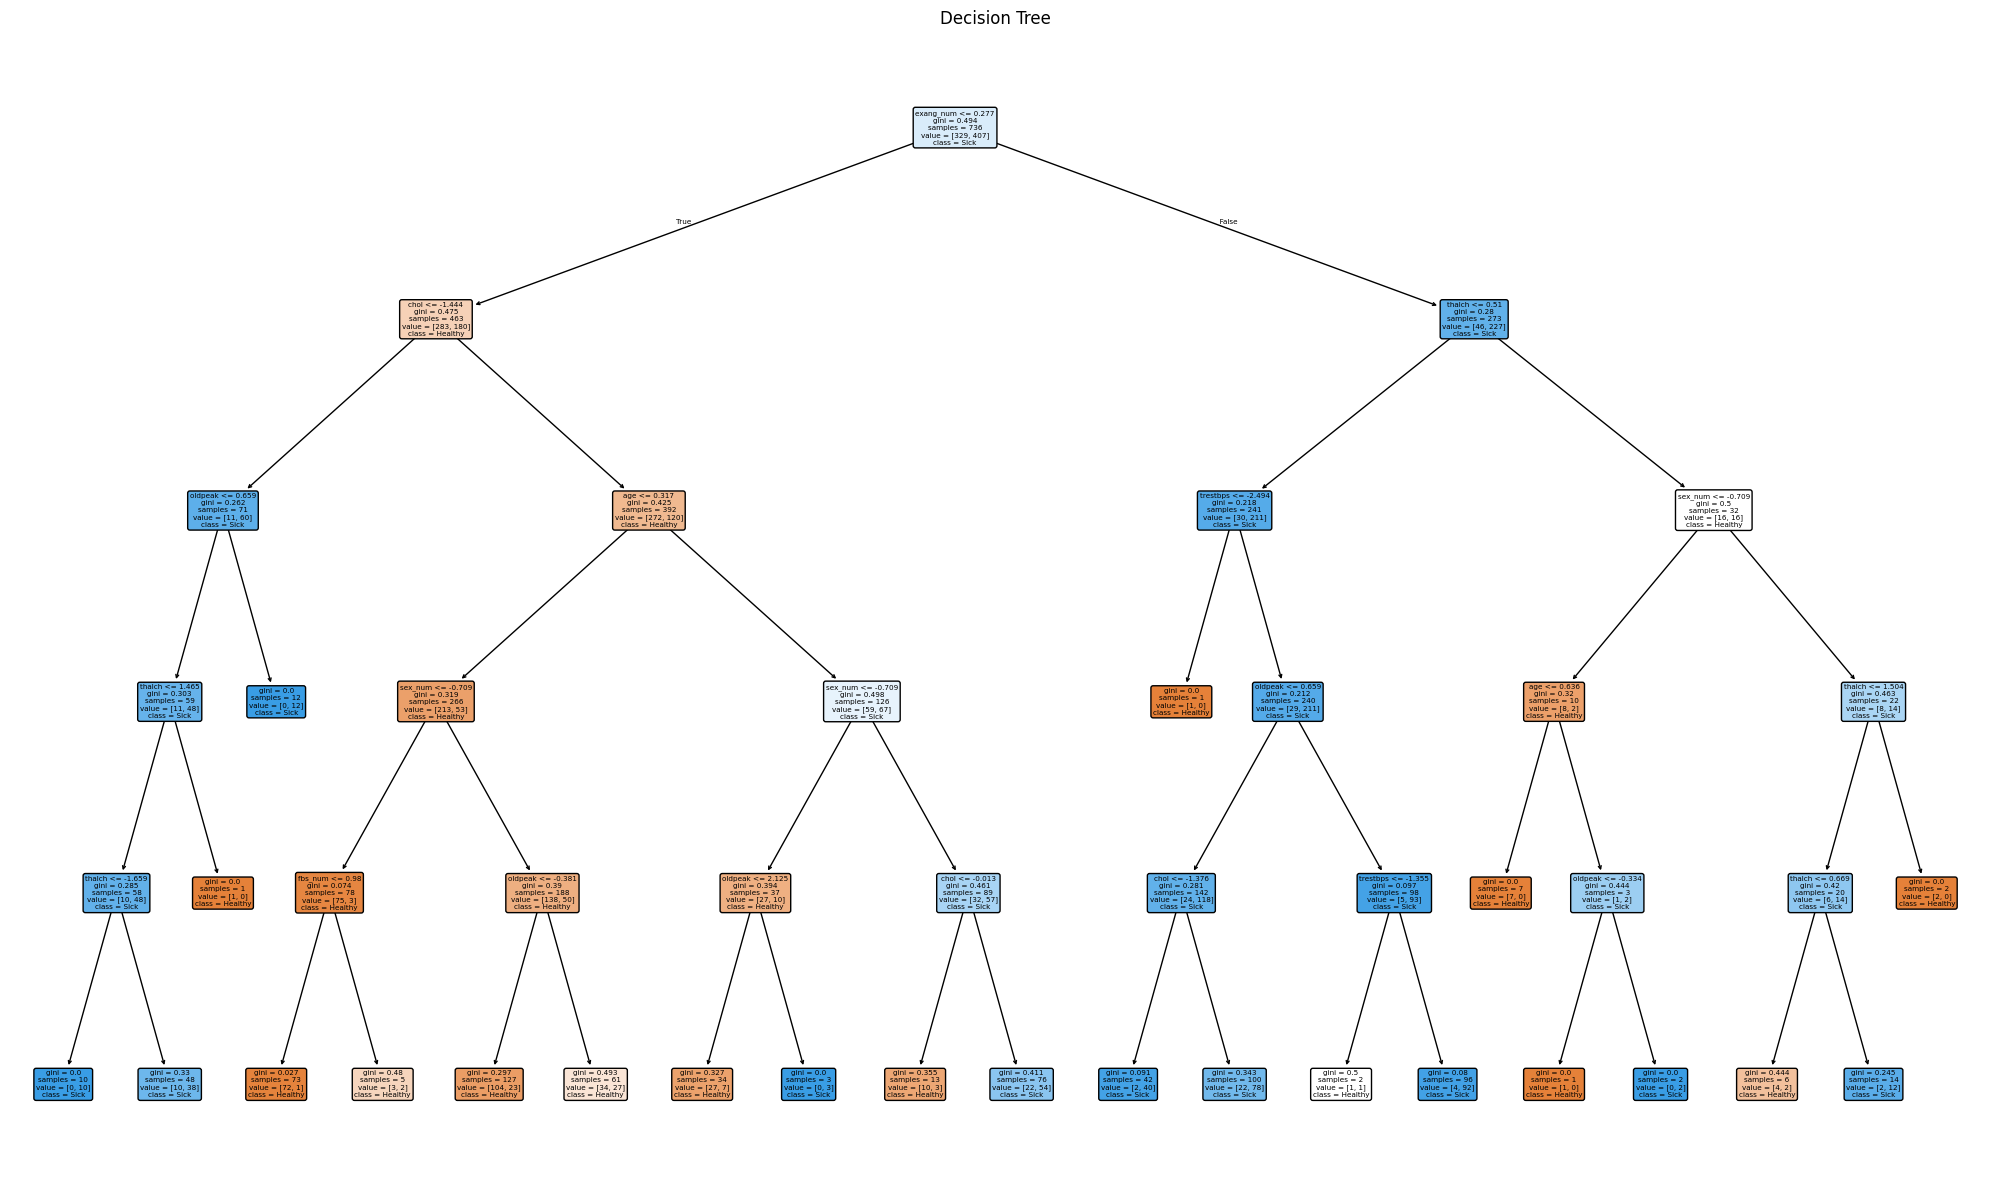

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import accuracy_score, f1_score, classification_report

df = pd.read_csv('/kaggle/date/heart_disease_uci.csv')
df['target'] = (df['num'] > 0).astype(int)

numerical_features = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']

X = df[numerical_features].copy()

for col in numerical_features:
    if X[col].isnull().sum() > 0:
        X[col].fillna(X[col].median(), inplace=True)

df['fbs_clean'] = df['fbs'].fillna(False)
X['fbs_num'] = df['fbs_clean'].astype(int)

df['exang_clean'] = df['exang'].fillna(False)
X['exang_num'] = df['exang_clean'].astype(int)

df['sex_clean'] = df['sex'].fillna('Male')
X['sex_num'] = (df['sex_clean'] == 'Male').astype(int)

if X['ca'].isnull().sum() > 0:
    X['ca'].fillna(X['ca'].median(), inplace=True)

y = df['target'].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)
y_pred_log = log_reg.predict(X_test)

svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)

dt_model = DecisionTreeClassifier(random_state=42, max_depth=5)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

accuracy_log = accuracy_score(y_test, y_pred_log)
f1_log = f1_score(y_test, y_pred_log)

accuracy_svm = accuracy_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)

accuracy_dt = accuracy_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)

print("Logistic Regression")
print(f"Accuracy: {accuracy_log:.4f}")
print(f"F1-score: {f1_log:.4f}")
print(classification_report(y_test, y_pred_log, target_names=['Healthy', 'Sick']))

print("\nSVM")
print(f"Accuracy: {accuracy_svm:.4f}")
print(f"F1-score: {f1_svm:.4f}")
print(classification_report(y_test, y_pred_svm, target_names=['Healthy', 'Sick']))

print("\nDecision Tree")
print(f"Accuracy: {accuracy_dt:.4f}")
print(f"F1-score: {f1_dt:.4f}")
print(classification_report(y_test, y_pred_dt, target_names=['Healthy', 'Sick']))

comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'SVM', 'Decision Tree'],
    'Accuracy': [accuracy_log, accuracy_svm, accuracy_dt],
    'F1-score': [f1_log, f1_svm, f1_dt]
})
print("\nComparison:")
print(comparison)

plt.figure(figsize=(8,5))
x = np.arange(len(comparison['Model']))
width = 0.35
plt.bar(x - width/2, comparison['Accuracy'], width, label='Accuracy')
plt.bar(x + width/2, comparison['F1-score'], width, label='F1-score')
plt.xlabel('Model')
plt.ylabel('Score')
plt.title('Model Comparison')
plt.xticks(x, comparison['Model'], rotation=15)
plt.legend()
plt.tight_layout()
plt.show()

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nFeature Importance:")
print(feature_importance)

plt.figure(figsize=(10,5))
plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.xlabel('Importance')
plt.title('Decision Tree Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nDecision Tree Rules:")
tree_rules = export_text(dt_model, feature_names=list(X.columns))
print(tree_rules)

plt.figure(figsize=(20,12))
plot_tree(dt_model, feature_names=X.columns, class_names=['Healthy', 'Sick'], filled=True, rounded=True)
plt.title('Decision Tree')
plt.tight_layout()
plt.show()